#Importing Libraries

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix


#Read and load dataset

In [143]:
df=pd.read_csv('/content/House_Pricing (1).csv')
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [144]:
df.tail()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,Fair,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,Fair,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,Fair,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,Fair,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287
21612,1523300157,14 October 2017,325000.0,2,0.75,1020.0,1076.0,2.0,No,NaN,Fair,7,1020.0,0,10,0,98144.0,47.5941,-122.299,1020.0,1357


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [146]:
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [147]:
#find the datatype
df.dtypes

,0
ID,int64
Date House was Sold,object
Sale Price,float64
No of Bedrooms,int64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Waterfront View,object
No of Times Visited,object


#Check and Remove Duplicates

In [148]:
#check duplicate rows and remove them
df.duplicated().sum()

np.int64(0)

In [149]:
#check duplicate columns and remove them
df.T.duplicated().sum()

np.int64(0)

Handling missing values

In [150]:
#check missing values
df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [151]:
#check % of missing values
(df.isna().sum()/len(df)*100)

,0
ID,0.000000
Date House was Sold,0.000000
Sale Price,0.018507
No of Bedrooms,0.000000
No of Bathrooms,0.018507
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
No of Floors,0.000000
Waterfront View,0.000000
No of Times Visited,90.172581


In [152]:
#drop column with more than 60-70% missing values
df=(df.drop(columns=["No of Times Visited","ID"]))

In [153]:
df.isna().sum()

,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0
Overall Grade,0


In [154]:
#numerical values
num_cols=df.select_dtypes(include='number').columns

In [155]:
#categorical values
cat_cols=df.select_dtypes(include='object').columns

In [156]:
df.isna().sum()

,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0
Overall Grade,0


In [157]:
# Columns with missing values
missing_num_cols = ["Area of the House from Basement (in Sqft)","Living Area after Renovation (in Sqft)"]
# Fill missing values with median
for col in missing_num_cols:
    df[col] = df[col].fillna(df[col].median())

In [158]:
df.isna().sum()

,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0
Overall Grade,0


In [159]:
#splitting into year and month
df['Date House was Sold'] = pd.to_datetime(df['Date House was Sold'])
df['Year'] = df['Date House was Sold'].dt.year
df['Month'] = df['Date House was Sold'].dt.month

Encoding

In [160]:
#label encoding
label_cols=["Condition of the House"]
le=LabelEncoder()
for cols in label_cols:
  df[cols]=le.fit_transform(df[cols])


In [161]:
#onehot encoding
df = pd.get_dummies(df,columns=["Waterfront View"],drop_first=True,dtype=int)


In [162]:
df.head()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Year,Month,Waterfront View_Yes
0,2017-10-14,221900.0,3,1.00,1180.0,5650.0,1.0,2,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650,2017,10,0
1,2017-12-14,538000.0,3,2.25,2570.0,7242.0,2.0,2,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639,2017,12,0
2,2016-02-15,180000.0,2,1.00,770.0,10000.0,1.0,2,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062,2016,2,0
3,2017-12-14,604000.0,4,3.00,1960.0,5000.0,1.0,1,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000,2017,12,0
4,2016-02-15,510000.0,3,2.00,1680.0,8080.0,1.0,2,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503,2016,2,0


Outlier Removal

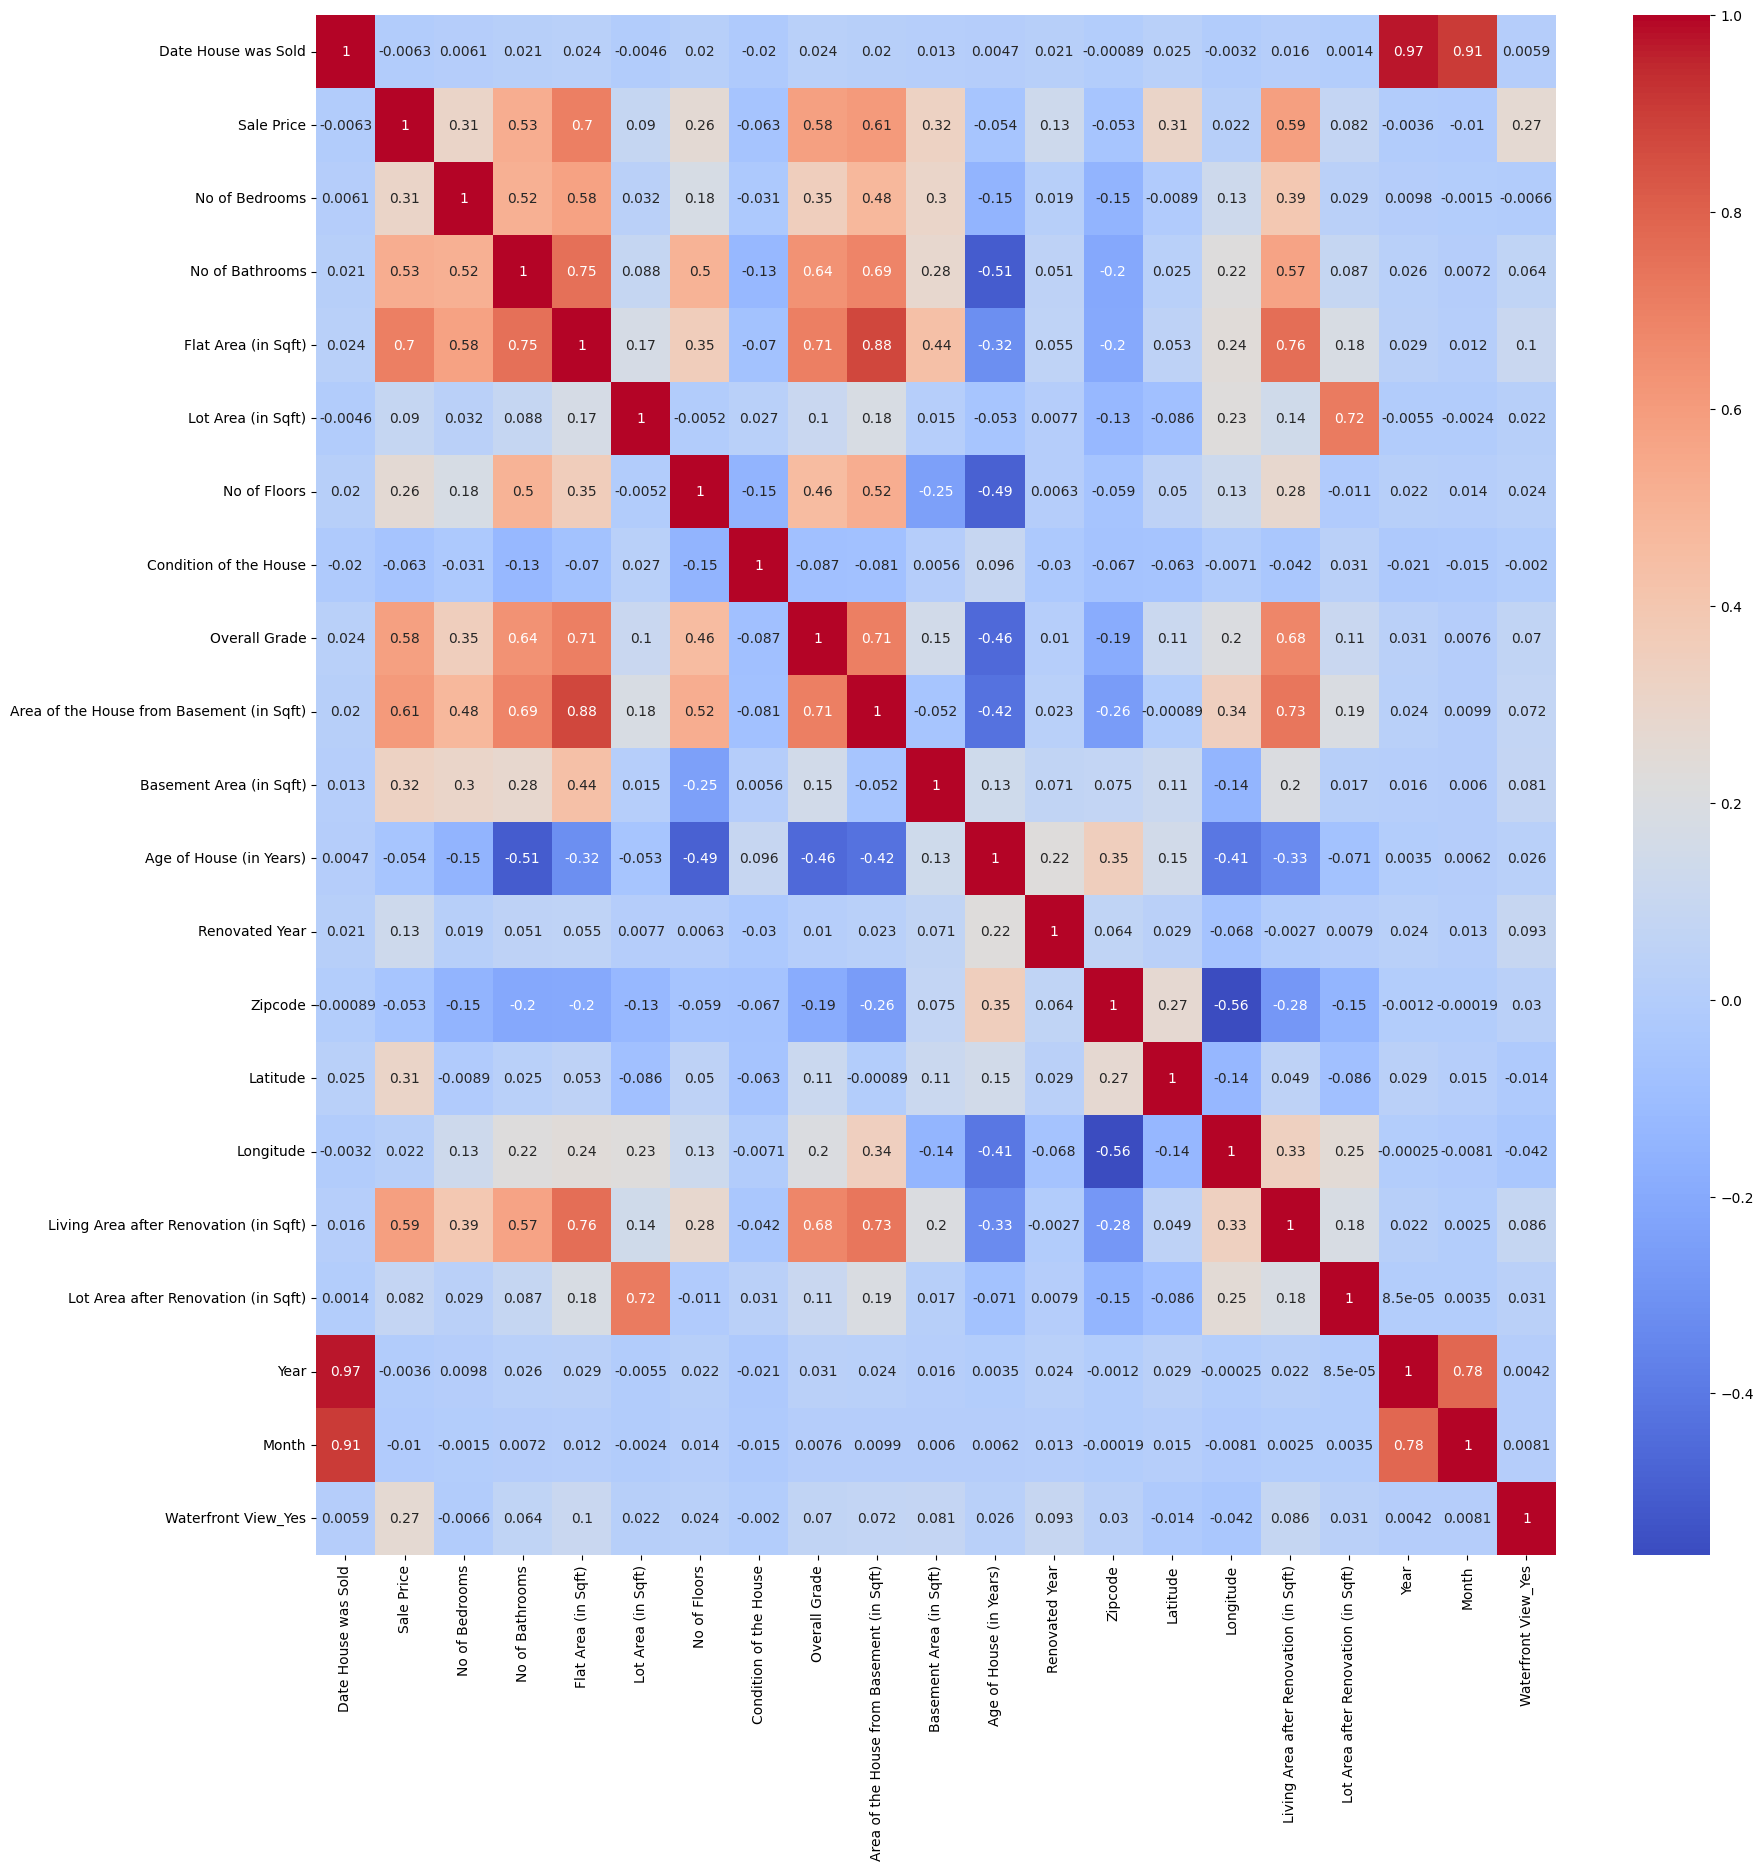

In [163]:
#correlation matrix
corr = df.select_dtypes(exclude="object").corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.show()

In [164]:
columns_to_select = ['Basement Area (in Sqft)', 'Living Area after Renovation (in Sqft)', 'Area of the House from Basement (in Sqft)','Sale Price']
columns_to_drop = [col for col in df.columns if col not in columns_to_select]
df=df.drop(columns=columns_to_drop)

In [165]:
df.head()

,Sale Price,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Living Area after Renovation (in Sqft)
0,221900.0,1180.0,0,1340.0
1,538000.0,2170.0,400,1690.0
2,180000.0,770.0,0,2720.0
3,604000.0,1050.0,910,1360.0
4,510000.0,1680.0,0,1800.0


In [166]:
columns_to_select.remove("Sale Price")

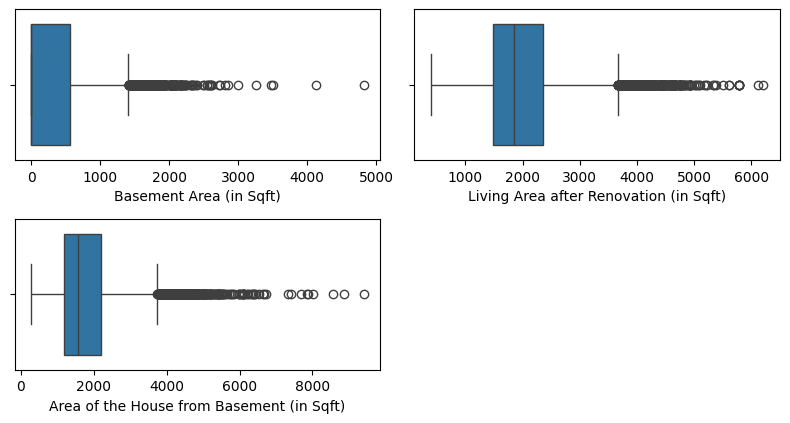

In [167]:
# Checking outliers on each columns
columns = columns_to_select
plt.figure(figsize=(8, 6))

for i, col in enumerate(columns):
  plt.subplot(len(columns), 2, i + 1)
  sns.boxplot(x = df[col])

plt.tight_layout()
plt.show()

In [168]:
#IQR Method
columns = columns_to_select

for col in columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    IQR = q3 - q1

    upper_bound = q3 + 1.5 * IQR
    lower_bound = q1 - 1.5 * IQR
    outlier = df[(df[col] < lower_bound) |(df[col] > upper_bound)]



In [169]:
# Remove rows where the target variable is missing
df = df.dropna(subset=["Sale Price"])

# Define X and y again after removing missing target values
X = df.drop(columns=["Sale Price"])
y = df["Sale Price"]


In [170]:
df.isna().sum()

,0
Sale Price,0
Area of the House from Basement (in Sqft),0
Basement Area (in Sqft),0
Living Area after Renovation (in Sqft),0


In [171]:
#splitting the data
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

Scaling

In [172]:
#Scaling
scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Model Building and Evaluation

##Linear Regression

In [173]:
#  Linear Regression
lr= LinearRegression()
# Train the model
lr.fit(X_train, y_train)

LinearRegression()

In [174]:
#Predict the model
y_pred_lr= lr.predict(X_test)

In [175]:
#evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE  :", mae_lr)
print("MSE  :", mse_lr)
print("RMSE :", rmse_lr)
print("R²   :", r2_lr)

Linear Regression
MAE  : 173295.82414893975
MSE  : 72613769209.9059
RMSE : 269469.4216602431
R²   : 0.5020768272347216


##RandomForest

In [176]:
#RandomForest Model
rf = RandomForestRegressor(n_estimators=100,random_state=42)
#Train the model
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [177]:
y_pred_rf = rf.predict(X_test)


In [178]:
#evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression")
print("MAE  :", mae_rf)
print("MSE  :", mse_rf)
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)

Random Forest Regression
MAE  : 168289.47821689773
MSE  : 66578862677.967896
RMSE : 258028.802031804
R²   : 0.5434590587373735


##SVM

In [179]:
#SVM
svm = SVR(kernel="rbf")
svm.fit(X_train, y_train)

SVR()

In [180]:
y_pred_svm = svm.predict(X_test)


In [181]:
#evaluation
mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
r2_svm = r2_score(y_test, y_pred_svm)
print("SVM Regression")
print("MAE  :", mae_svm)
print("MSE  :", mse_svm)
print("RMSE :", rmse_svm)
print("R²   :", r2_svm)

SVM Regression
MAE  : 226090.0890574813
MSE  : 154647766950.4024
RMSE : 393252.8028512987
R²   : -0.06044222216886541


##XGBoost

In [182]:
xgb = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=6,random_state=42)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [183]:
#prediction
y_pred_xgb = xgb.predict(X_test)

In [184]:
#evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb= r2_score(y_test, y_pred_xgb)

print("XGB Regression")
print("MAE  :", mae_xgb)
print("MSE  :", mse_xgb)
print("RMSE :", rmse_xgb)
print("R²   :", r2_xgb)

XGB Regression
MAE  : 161210.12033274525
MSE  : 62088720203.30341
RMSE : 249176.0827272622
R²   : 0.5742486185065432


In [185]:
# Model Comparison

results = pd.DataFrame({"Model": ["Linear Regression", "Random Forest", "SVM", "XGBoost"],
"MAE": [mae_lr,mae_rf,mae_svm,mae_xgb],
"MSE": [mse_lr,mse_rf, mse_svm,mse_xgb],
"RMSE": [rmse_lr,rmse_rf,rmse_svm,rmse_xgb],
"R²": [r2_lr,r2_rf,r2_svm,r2_xgb]})
results

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,173295.824149,7.261377e+10,269469.421660,0.502077
1,Random Forest,168289.478217,6.657886e+10,258028.802032,0.543459
2,SVM,226090.089057,1.546478e+11,393252.802851,-0.060442
3,XGBoost,161210.120333,6.208872e+10,249176.082727,0.574249


#Conclusion

Based on the evaluation metrics, XGBoost is the best-performing model among the four models tested. It achieved the highest R² score 0.5742. This indicates that XGBoost provides more accurate predictions  compared with Linear Regression, Random Forest, and SVM. Random Forest showed the second-best performance, while SVM performed the worst with a negative R² score. Therefore, **XGBoost** Regression can be selected as the final model for prediction.